# **PROJECT OVERVIEW**
Build a ML system that matches resumes with relevant jobs using **TF-IDF** and **Cosine Similarity**.

### **Project Aim:**
1. Data load and clean from job dataset.
2. Found feature from text using TF-IDF vectorization.
3. Finding out job similarities with resume using Cosine Similarity.
4. Showed Top 10 matching jobs.
5. Created visualizations.

## **Installing pandas scikit-learn streamlit PyPDF2**

In [ ]:
!pip install pandas scikit-learn streamlit PyPDF2

## **Importing libraries**

In [20]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## **Dataset load**

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Resume Matching project/Data/job_dataset.csv')
print(f"Total job: {len(df)}")



Total job: 1068


## **Data clean**

## **Clean dataset**

In [60]:
def clean_text(text):
    if text is None or pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

## **Feature Engineering**

In [61]:
df['description'] = df['Title'] + " " + df['Skills']
df['description'] = df['description'].apply(clean_data)

def get_experience(exp):
    nums = re.findall(r'\d+', str(exp))
    return int(nums[0]) if nums else 0

print("Feature engineering have done!")
print(f"Data is ready: {df.shape}")


Feature engineering have done!
Data is ready: (1068, 11)


## **Input your resume**

In [62]:
print("\nwrite your resume:")
print("(press ENTER  after writing)\n")
resume = input().strip()
if resume == "":

    resume = "I am a Developer with C# ASP.NET MVC SQL Server"
    print(f"Default resume: {resume}")

resume = clean_data(resume)
print(f"REasume readyyyyy")


write your resume:
(press ENTER  after writing)

Data scientist
REasume readyyyyy


## **TF IDF Matching**

In [63]:
print("\nmatching continuous..")

vectorizer = TfidfVectorizer(max_features=1000)
all_text = [resume] + df['description'].tolist()
vectors = vectorizer.fit_transform(all_text)

# similarity calculation
similarities = cosine_similarity(vectors[0:1], vectors[1:])[0]
df['match'] = (similarities * 100).round(2)

print("matching done")


matching continuous..
matching done


## **LOOKING top 10 jobs**

In [64]:
top_jobs = df.sort_values('match', ascending=False).head(10)

print("\n" + "=" * 70)
print("10 best job for youuuu")
print("=" * 70)

for i, (idx, row) in enumerate(top_jobs.iterrows(), 1):
    print(f"{i}. {row['Title']}")
    print(f"   Match: {row['match']}%")
    print(f"   level {row['ExperienceLevel']}")
    print(f"   Job ID: {row['JobID']}")
    print("-" * 50)


10 best job for youuuu
1. Data Analyst / Data Scientist Intern
   Match: 40.93%
   level Fresher
   Job ID: DS-F3
--------------------------------------------------
2. Data Scientist - Entry Level
   Match: 39.63%
   level Fresher
   Job ID: DS-F1
--------------------------------------------------
3. Entry Level Data Scientist
   Match: 38.89%
   level Fresher
   Job ID: DS-F6
--------------------------------------------------
4. Fresher Data Scientist
   Match: 36.44%
   level Fresher
   Job ID: DS-F8
--------------------------------------------------
5. Data Scientist - Fresher
   Match: 34.4%
   level Fresher
   Job ID: DS-F4
--------------------------------------------------
6. Junior Data Scientist
   Match: 29.52%
   level Fresher
   Job ID: DS-F2
--------------------------------------------------
7. Data Scientist - Experienced
   Match: 28.84%
   level Mid-Senior
   Job ID: DS-E1
--------------------------------------------------
8. Lead Data Scientist
   Match: 28.22%
   leve

## **Looking graphs**

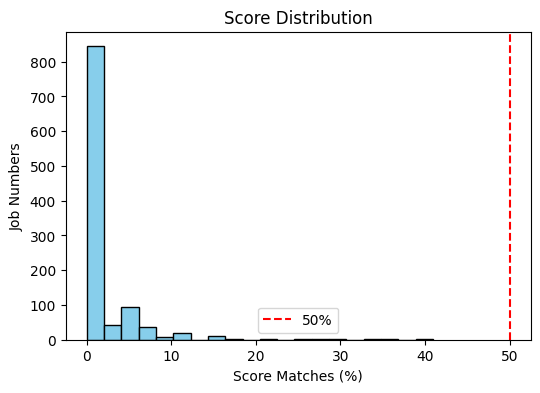

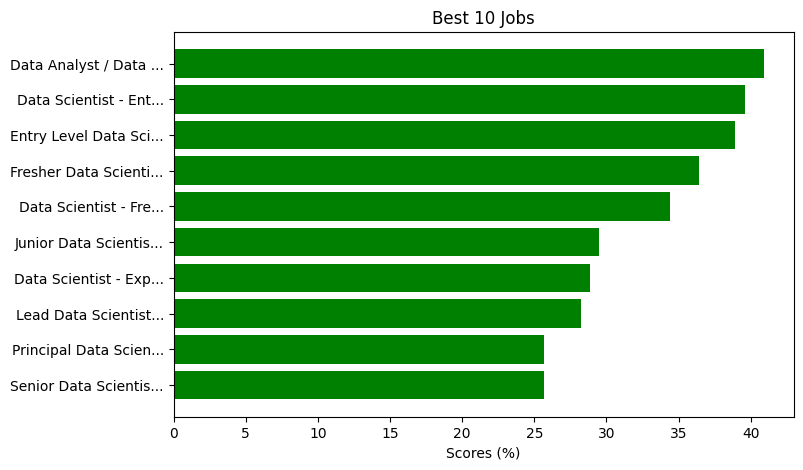

In [65]:
# subplot 1 for score distribution
plt.figure(figsize=(6, 4))
plt.hist(df['match'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(x=50, color='red', linestyle='--', label='50%')
plt.title('Score Distribution')
plt.xlabel('Score Matches (%)')
plt.ylabel('Job Numbers')
plt.legend()
plt.savefig('/content/drive/MyDrive/Resume Matching project/Figures/score_distribution.png', dpi=300)
plt.show()


# subplot 2 for top 10 jobs
plt.figure(figsize=(8, 5))
y_pos = range(len(top_jobs))
plt.barh(y_pos, top_jobs['match'], color='green')
plt.yticks(y_pos, top_jobs['Title'].str[:20] + '...')
plt.xlabel('Scores (%)')
plt.title('Best 10 Jobs')
plt.gca().invert_yaxis()
plt.savefig('/content/drive/MyDrive/Resume Matching project/Figures/top_10_jobs.png', dpi=300, bbox_inches='tight')
plt.show()

## **Summary for matching**

In [66]:
print("\n" + "=" * 50)
print("Summary:")
print("=" * 50)
print(f"Good matched (70%+): {len(df[df['match']>=70])} ")
print(f"Medium matched (40-69%): {len(df[(df['match']>=40) & (df['match']<70)])} ")
print(f"Low matched (below 40%): {len(df[df['match']<40])} ")


Summary:
Good matched (70%+): 0 
Medium matched (40-69%): 1 
Low matched (below 40%): 1067 


In [71]:
df.to_csv('/content/drive/MyDrive/Resume Matching project/my_job_matches.csv', index=False)
print("\nResult has been saved: my_job_matches.csv")
print("=" * 42)


Result has been saved: my_job_matches.csv


In [100]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# Load Model
@st.cache_resource
def load_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

model = load_model()

st.title("Resume Matcher")
st.write("Match your profile against the Job Bank")

# Input
resume_text = st.text_area("Paste your Resume here")
df = pd.read_csv('/content/drive/MyDrive/Resume Matching project/Data/job_dataset.csv')

if st.button("Find Best Jobs"):
    if resume_text:
        df['context'] = df['Title'] + " " + df['Skills'] + " " + df['Responsibilities']
        job_embs = model.encode(df['context'].tolist(), convert_to_tensor=True)
        res_emb = model.encode(resume_text, convert_to_tensor=True)

        scores = util.cos_sim(res_emb, job_embs)[0].cpu().numpy() * 100
        df['Score'] = scores

        top_matches = df.sort_values(by='Score', ascending=False).head(5)

        st.subheader("Top 5 Job Matches:")
        for i, row in top_matches.iterrows():
            st.write(f"**{row['Title']}** - Match: {row['Score']:.2f}%")
            st.progress(int(row['Score']))
    else:
        st.warning("Please paste your resume!")

Writing app.py


In [ ]:
!npm install -g localtunnel
!streamlit run app.py & npx localtunnel --port 8501

## **Project complete**

##  **What id did in this project, right??**

| Step | work | Library |
|-----|-----|-----------|
| 1 | CSV file load | pandas |
| 2 | data cleaning | re, pandas |
| 3 | Feature engineering| pandas |
| 4 | user input | input() |
| 5 | TF-IDF vectorize | sklearn |
| 6 | Cosine Similarity | sklearn |
| 7 | visualization | matplotlib |